# ini

In [3]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('..')
from fun_gilles import *
import pandas as pd
import pickle
colors = plt.get_cmap('Set2').colors
title_fs = 16
label_fs = 15
tick_fs = 14
legend_fs = 14

In [4]:
def plot_gillespie(abundances, times, V, SPECIES, xlim= None, ylim= None):
    colors = plt.get_cmap('Set2').colors
    colors = colors

    fig, axes = plt.subplots(nrows=2, ncols=1) 

    # --- Subplot 1: Concentration ---
    ax1 = axes[0]
    for i in range(len(SPECIES)):
        # Calculate concentration = Abundance / Volume
        ax1.plot(times, abundances[:, i] / V, label=SPECIES[i], color=colors[i], alpha=0.9)
    ax1.grid(True, linestyle='--', alpha=0.3)
    ax1.set_xlabel("Time", fontsize= label_fs)
    ax1.set_ylabel("Concentration", fontsize= label_fs)
    ax1.set_title("Concentration Evolution", fontsize= title_fs)
    ax1.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="SPECIES", fontsize= legend_fs)
    ax1.tick_params(axis='both', labelsize=tick_fs)

    # --- Subplot 2: Volume ---
    ax2 = axes[1]
    ax2.plot(times, V, color='gray')
    ax2.grid(True, linestyle='--', alpha=0.3)
    ax2.set_xlabel("Time", fontsize= label_fs)
    ax2.set_ylabel("Volume", fontsize= label_fs)
    ax2.set_title("Volume Evolution", fontsize= title_fs)
    ax2.tick_params(axis='both', labelsize=tick_fs)
    ax2.set_yscale('log')
    if xlim is not None:
        ax1.set_xlim(0, xlim)
        ax2.set_xlim(0, xlim)
    if ylim is not None:
        ax2.set_ylim(0, ylim)
        
    plt.tight_layout(rect=[0, 0, 1, 1]) 
    plt.show()

In [5]:
def plot_deterministic(concentrations, times, V, SPECIES):
    colors = plt.get_cmap('Set2').colors
    colors = colors
    linestyles = [ "-", "--", "-","--"]

    fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True) 

    # --- Subplot 1: Concentration ---
    ax1 = axes[0]
    for i in range(len(SPECIES)):
        # Calculate concentration = Abundance / Volume
        ax1.plot(times, concentrations[i], label=SPECIES[i], color=colors[i], alpha=0.9, linestyle= linestyles[i])
    ax1.grid(True, linestyle='--', alpha=0.3)
    ax1.set_xlabel("Time", fontsize= label_fs)
    ax1.set_ylabel("Concentration", fontsize= label_fs)
    ax1.set_title("Concentration Evolution", fontsize= title_fs)
    ax1.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="SPECIES", fontsize= legend_fs)
    ax1.tick_params(axis='both', labelsize=tick_fs)

    # --- Subplot 2: Volume ---
    ax2 = axes[1]
    ax2.plot(times, V, color='gray')
    ax2.grid(True, linestyle='--', alpha=0.3)
    ax2.set_xlabel("Time", fontsize= label_fs)
    ax2.set_ylabel("Volume", fontsize= label_fs)
    ax2.set_title("Volume Evolution", fontsize= title_fs)
    ax2.tick_params(axis='both', labelsize=tick_fs)
    ax2.set_yscale('log')
   
    plt.tight_layout(rect=[0, 0, 1, 1]) 
    plt.show()

In [6]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def plot_deterministic_both(concentrations_to, times_to, V_to, SPECIES_to,
                            concentrations_int, times_int, V_int, SPECIES_int):
    
    # Safely load colors
    cmap_colors = list(plt.get_cmap('Set2').colors)
    linestyles = ["-", "--"]

    # Adjusted figsize slightly to make room for the external legend
    fig, axes = plt.subplots(figsize=(5,5), nrows=2, ncols=1) 

    # --- Subplot 1: Concentration ---
    ax1 = axes[0]
    
    # We use a dictionary to store unique species and their assigned colors
    species_color_map = {}
    
    for i in range(len(SPECIES_to)):
        color = cmap_colors[i % len(cmap_colors)]
        species_color_map[SPECIES_to[i]] = color
        # Removed label parameter here since we are building a custom legend
        ax1.plot(times_to, concentrations_to[i], color=color, 
                 alpha=0.5, linestyle=linestyles[0], linewidth=2)
                 
    for i in range(len(SPECIES_int)):
        color = cmap_colors[i % len(cmap_colors)]
        species_color_map[SPECIES_int[i]] = color
        # Removed label parameter here
        ax1.plot(times_int, concentrations_int[i], color=color, 
                 alpha=0.7, linestyle=linestyles[1], linewidth=2.5)
                 
    ax1.grid(True, linestyle='--', alpha=0.3)
    ax1.set_ylabel("Concentration", fontsize=label_fs)
    ax1.set_xlabel("Time", fontsize=label_fs)
    ax1.tick_params(axis='both', labelsize=tick_fs)
    ax1.set_title("(A)", loc="left",x = -0.05, y=1, pad=10, fontsize=16)
    # --- Subplot 2: Volume ---
    ax2 = axes[1]
    ax2.plot(times_to, V_to, color='black', linestyle=linestyles[0], alpha=0.5, linewidth=2)
    ax2.plot(times_int, V_int, color='black', linestyle=linestyles[1], alpha=0.7, linewidth=2.5)
    
    ax2.grid(True, linestyle='--', alpha=0.3)
    ax2.set_xlabel("Time", fontsize=label_fs)
    ax2.set_ylabel("Volume", fontsize=label_fs)
    ax2.tick_params(axis='both', labelsize=tick_fs)
    ax2.set_yscale('log')
    
    # --- Custom Legend ---
    # 1. Create color patches for every unique species plotted
    species_handles = [Patch(color=color, label=sp) for sp, color in species_color_map.items()]
    
    # 2. Add the Volume patch
    species_handles.append(Patch(color='black', label='Volume'))
    
    # 3. Create line styles for the two different models
    line_to = Line2D([0], [0], color='gray', linestyle=linestyles[0], alpha=0.5, linewidth=2, label='Third order')
    line_int = Line2D([0], [0], color='gray', linestyle=linestyles[1], alpha=0.7, linewidth=2.5, label='Intermediates')
    
    spacer = Patch(color='none', label='')
    
    # Combine everything
    handles = species_handles + [spacer, line_to, line_int]
    
    # Attach to the FIGURE, perfectly centered on the right side
    fig.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.05,1), 
               borderaxespad=0., fontsize=legend_fs)
    

    # Adjust layout to squeeze the plots over and make room for the legend
    plt.tight_layout(rect=[0, 0, 1, 1])
    plt.savefig("../figures_TFM/third_order.png", bbox_inches='tight', dpi=300)

    plt.show()

# intermediates

In [5]:
def odes_intermediates(t, X):
    V, ab, cd, acd, cab = X
    a, b, c, d = 1, 1, 1, 1
    k1, k2, k3, k4, k5, k6, k7, k8 = 1e10,1e11,10,1,1e10,1e11,10,1
    fi = 0.2
    dVdt = (V/fi) * (k3 * b * acd + k7 * d * cab - k4 * ab * cd - k8 * ab * cd)
    dabdt = k3 * b * acd + k6 * cab + k7 * cab * d - k4 * ab * cd - k5 * ab * c - k8 * cd * ab - (ab / V) * dVdt
    dcddt = k3 * b * acd + k7 * cab * d + k2 * acd - k4 * ab * cd - k1 * a * cd - k8 * cd * ab - (cd / V) * dVdt
    dacddt = k4 * ab * cd + k1 * a * cd - k3 * b * acd - k2 * acd - (acd / V) * dVdt
    dcabdt = k5 * ab * c + k8 * cd * ab - k6 * cab - k7 * cab * d - (cab / V) * dVdt
    return [dVdt, dabdt, dcddt, dacddt, dcabdt]
    

t_span = (0, 10)
y0 = [1000, 0.2, 0, 0, 0]
sol = solve_ivp(odes_intermediates, t_span, y0, t_eval=np.linspace(0, 10, 5000))

plot_deterministic(sol.y[1:], sol.t, sol.y[0], ['ab', 'cd', 'acd', 'cab'])

KeyboardInterrupt: 

In [32]:
abundancias, tiempos, volumenes = chemistry(method= "Protocell",
                                            iterations= 1e6,
                                            file = "../examples/reactions_autocat.txt",
                                            initial_food= [100] * 4 + [20] * 1 + [0] * 3,
                                            k = [1e2,1e4,1e2,1,1e2,1e4,1e2,1],
                                            V = 100,                                            
                                            )



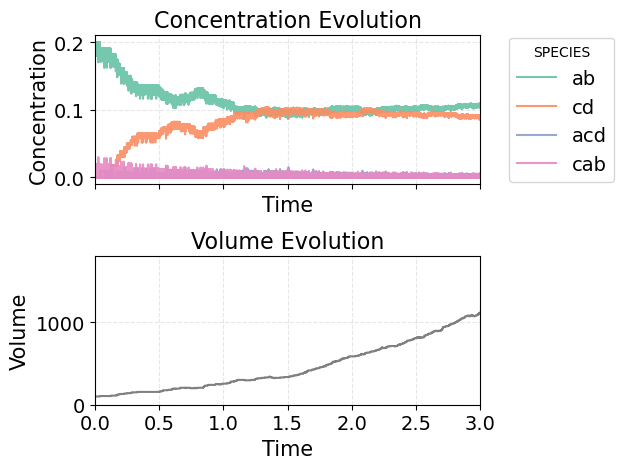

In [30]:
plot_gillespie(abundancias[:, 4:], tiempos, volumenes, ['ab', 'cd', 'acd', 'cab'], xlim= 3, ylim= 1800)

dict_keys([10])


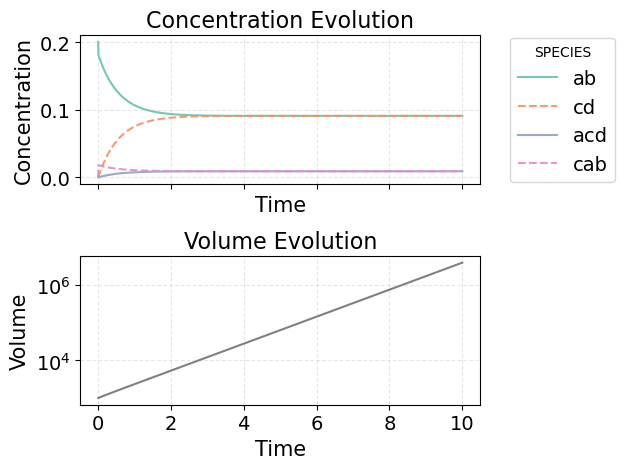

In [8]:
results = {}
with open("odes_intermediates_solution.pkl", "rb") as f:
    while True:
        try:
            results = pickle.load(f)
        except EOFError:
            break

print(results.keys())
sol = results[10]        
        

plot_deterministic(sol.y[1:], sol.t, sol.y[0], ['ab', 'cd', 'acd', 'cab'])

# third order 

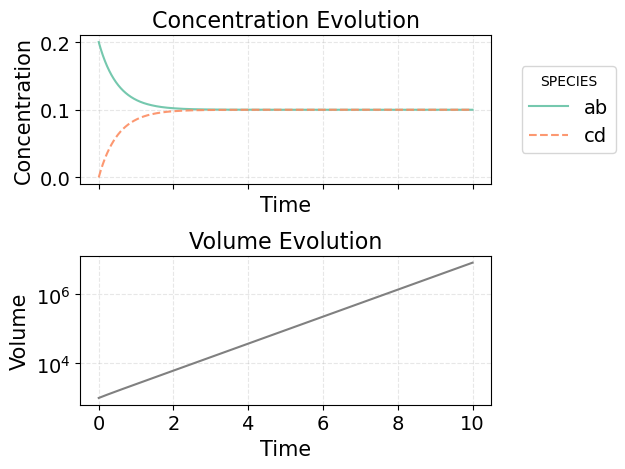

array([1.00000000e+03, 1.00200160e+03, 1.00400562e+03, ...,
       8.27874119e+06, 8.29365982e+06, 8.30860501e+06])

In [10]:
def odes_thirdorder(t, X):
    V, ab, cd= X
    a, b, c, d = 1, 1, 1, 1
    k1, k2, k3, k4 = 1,1,1,1
    fi = 0.2
    # with concentrations
    dVdt = (V/fi) * (k1 * a * b * cd - k2 * ab * cd + k3 * ab * c * d - k4 * ab * cd)
    dabdt = k1 * a * b * cd - k2 * ab * cd - (ab / V) * dVdt # dilution: as the volume grows, concentration decreases
    dcddt = k3 * ab * c * d - k4 * ab * cd - (cd / V) * dVdt
    return [dVdt, dabdt, dcddt]
    

t_span = (0, 10)
y0 = [1000, 0.2, 0]
sol2 = solve_ivp(odes_thirdorder, t_span, y0, t_eval=np.linspace(0, 10, 5000))

plot_deterministic(sol2.y[1:], sol2.t, sol2.y[0], ['ab', 'cd'])
sol2.y[0]

In [14]:
abundancias, tiempos, volumenes = chemistry(method= "Protocell",
                                            iterations= 1e5,
                                            file = "../examples/third_order.txt",
                                            initial_food= [100] * 4 + [20] + [0],
                                            k = [1,1,1,1],
                                            V = 100                                       
                                            )


c_matrix(read_file("../examples/third_order.txt"), obtain_species(read_file("../examples/third_order.txt")), get_header("../examples/third_order.txt"))

array([[-1., -1.,  0.,  0.,  1.,  0.],
       [ 1.,  1.,  0.,  0., -1.,  0.],
       [ 0.,  0., -1., -1.,  0.,  1.],
       [ 0.,  0.,  1.,  1.,  0., -1.],
       [ 1.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  1.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  1.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  1.,  0.,  0.]])

C:\Users\cvzad\AppData\Local\Temp\ipykernel_29408\1145662920.py:32: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax2.set_ylim(0, ylim)


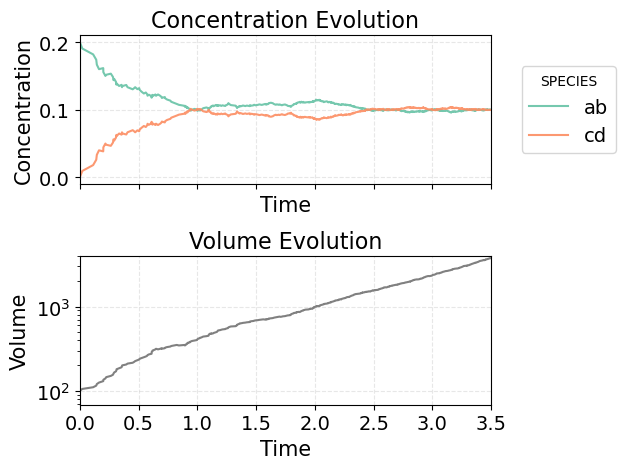

In [19]:
plot_gillespie(abundancias[:, 4:], tiempos, volumenes, ['ab', 'cd'], xlim= 3.5, ylim= 4000)

# both

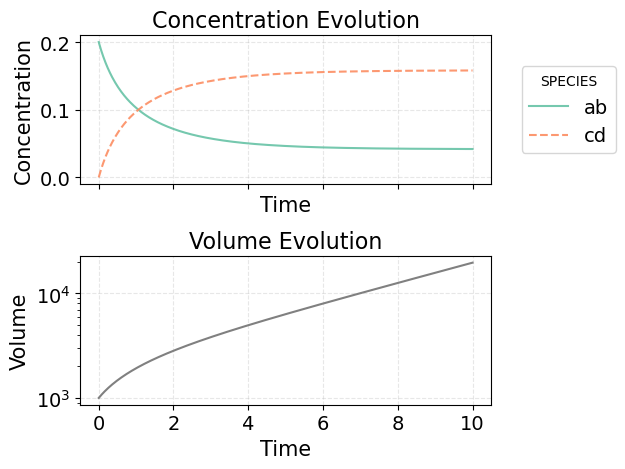

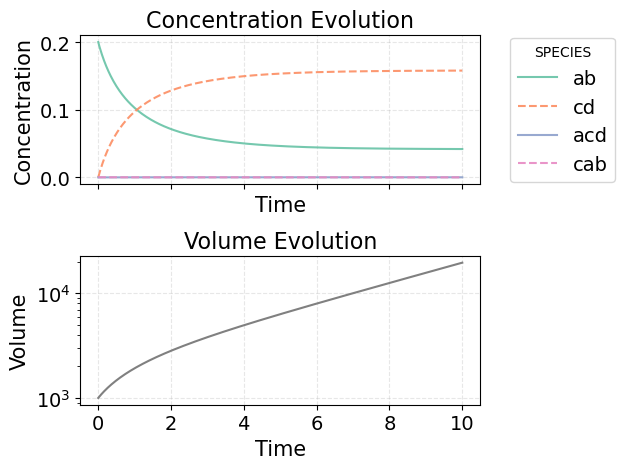

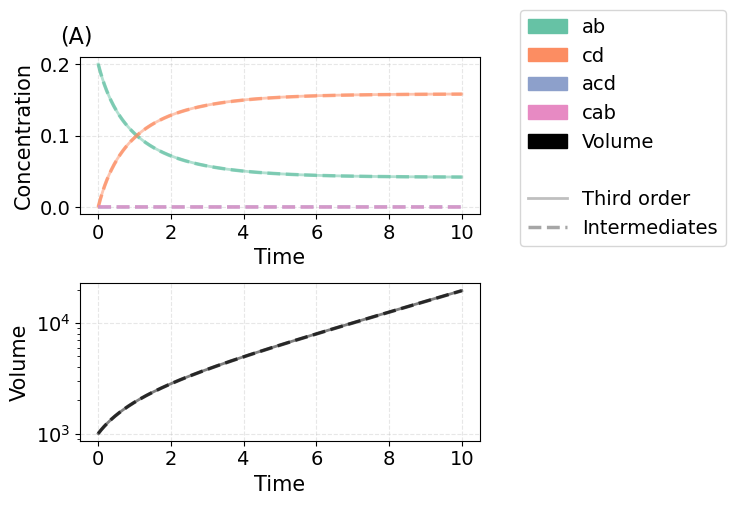

In [12]:
t_end = 10
def odes_thirdorder(t, X):
    V, ab, cd= X
    a, b, c, d = 1, 1, 1, 1
    k1, k2, k3, k4 = 0.1,1,1,1
    fi = 0.2
    # with concentrations
    dVdt = (V/fi) * (k1 * a * b * cd - k2 * ab * cd + k3 * ab * c * d - k4 * ab * cd)
    dabdt = k1 * a * b * cd - k2 * ab * cd - (ab / V) * dVdt # dilution: as the volume grows, concentration decreases
    dcddt = k3 * ab * c * d - k4 * ab * cd - (cd / V) * dVdt
    return [dVdt, dabdt, dcddt]

t_span = (0, t_end)
y0 = [1000, 0.2, 0]
sol2 = solve_ivp(odes_thirdorder, t_span, y0, t_eval=np.linspace(0, t_end, 500))

plot_deterministic(sol2.y[1:], sol2.t, sol2.y[0], ['ab', 'cd'])

# --- intermediates ---
K_intermediates = [1e4,1e7,1e2,1, 1e4,1e7,1e3,1]
def odes_intermediates(t, X, K_intermediates):
    V, ab, cd, acd, cab = X
    a, b, c, d = 1, 1, 1, 1
    k1, k2, k3, k4, k5, k6, k7, k8 = K_intermediates
    fi = 0.2
    dVdt = (V/fi) * (k3 * b * acd + k7 * d * cab - k4 * ab * cd - k8 * ab * cd)
    dabdt = k3 * b * acd + k6 * cab + k7 * cab * d - k4 * ab * cd - k5 * ab * c - k8 * cd * ab - (ab / V) * dVdt
    dcddt = k3 * b * acd + k7 * cab * d + k2 * acd - k4 * ab * cd - k1 * a * cd - k8 * cd * ab - (cd / V) * dVdt
    dacddt = k4 * ab * cd + k1 * a * cd - k3 * b * acd - k2 * acd - (acd / V) * dVdt
    dcabdt = k5 * ab * c + k8 * cd * ab - k6 * cab - k7 * cab * d - (cab / V) * dVdt
    return [dVdt, dabdt, dcddt, dacddt, dcabdt]
    

t_span = (0, t_end)
y0 = [1000, 0.2, 0, 0, 0]
sol = solve_ivp(odes_intermediates, t_span, y0, t_eval=np.linspace(0, t_end, 500), method='BDF', args=(K_intermediates,))

plot_deterministic(sol.y[1:], sol.t, sol.y[0], ['ab', 'cd', 'acd', 'cab'])

plot_deterministic_both(sol2.y[1:3], sol2.t, sol2.y[0], ['ab', 'cd'],
                        sol.y[1:], sol.t, sol.y[0], ['ab', 'cd', 'acd', 'cab'])


In [13]:
from scipy.integrate import solve_ivp
import numpy as np
import pickle



def odes_intermediates(t, X):
    V, ab, cd, acd, cab = X
    a, b, c, d = 1, 1, 1, 1
    k1, k2, k3, k4, k5, k6, k7, k8 = [1e4,1e6,1e4,1,1e4,1e6,1e4,1]
    fi = 0.2
    dVdt = (V/fi) * (k3 * b * acd + k7 * d * cab - k4 * ab * cd - k8 * ab * cd)
    dabdt = k3 * b * acd + k6 * cab + k7 * cab * d - k4 * ab * cd - k5 * ab * c - k8 * cd * ab - (ab / V) * dVdt
    dcddt = k3 * b * acd + k7 * cab * d + k2 * acd - k4 * ab * cd - k1 * a * cd - k8 * cd * ab - (cd / V) * dVdt
    dacddt = k4 * ab * cd + k1 * a * cd - k3 * b * acd - k2 * acd - (acd / V) * dVdt
    dcabdt = k5 * ab * c + k8 * cd * ab - k6 * cab - k7 * cab * d - (cab / V) * dVdt
    return [dVdt, dabdt, dcddt, dacddt, dcabdt]
    

t_span = (0, 1)
y0 = [1000, 0.2, 0, 0, 0]
sol = solve_ivp(odes_intermediates, t_span, y0, t_eval=np.linspace(0, 1, 5000), method='BDF')


Running for k'1 = 0.001
Running for k_3 = 1.0 (derived from k'1 = 0.001)


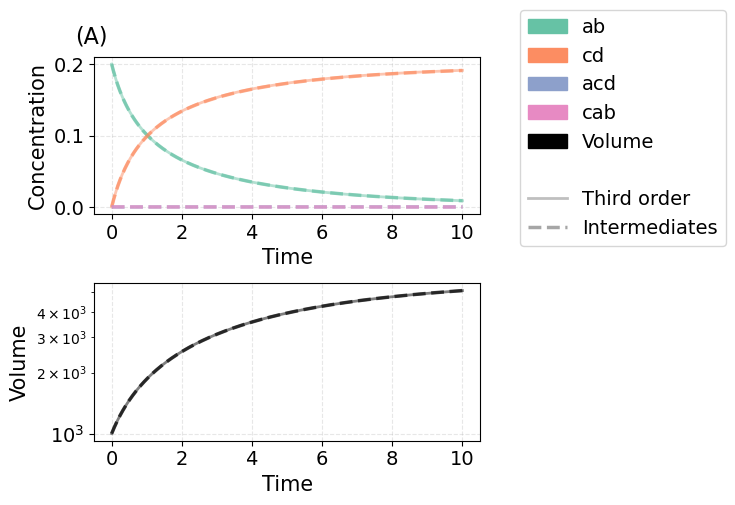

Running for k'1 = 0.01
Running for k_3 = 10.0 (derived from k'1 = 0.01)


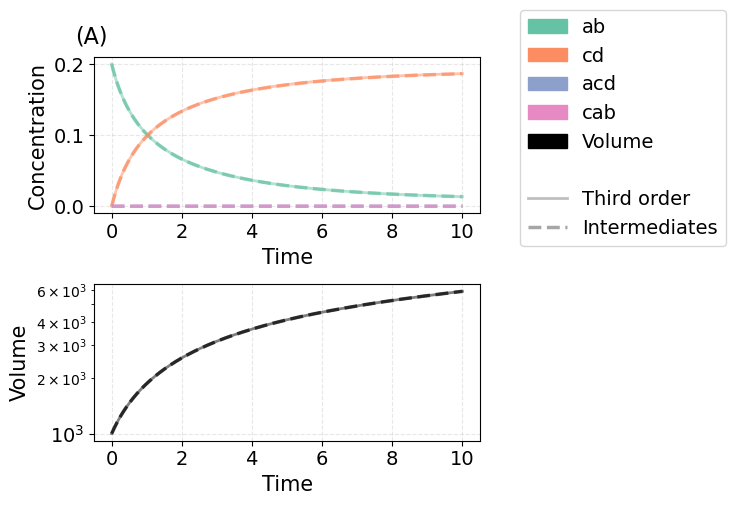

Running for k'1 = 0.1
Running for k_3 = 100.0 (derived from k'1 = 0.1)


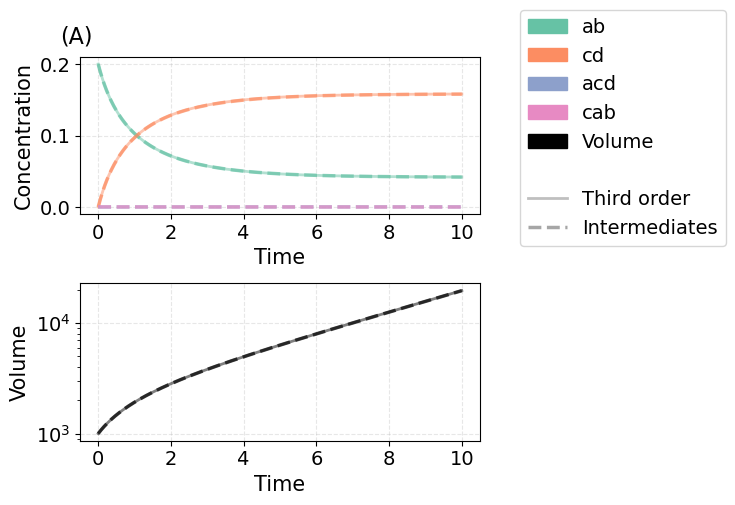

Running for k'1 = 1.0
Running for k_3 = 1000.0 (derived from k'1 = 1.0)


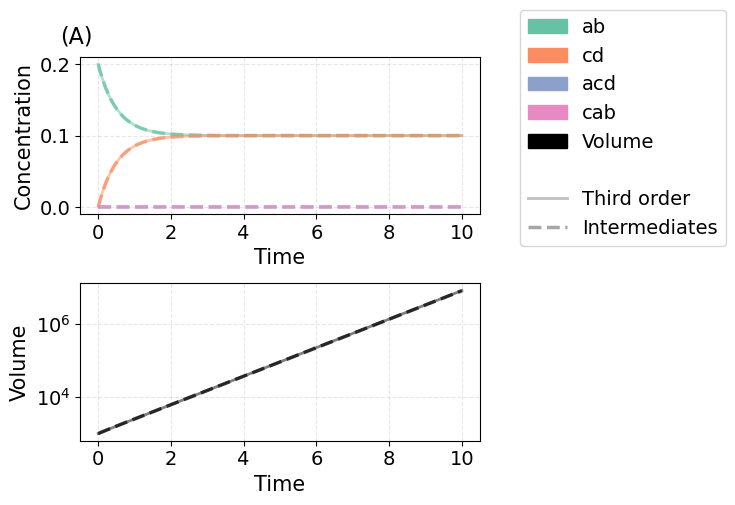

Running for k'1 = 10.0
Running for k_3 = 10000.0 (derived from k'1 = 10.0)


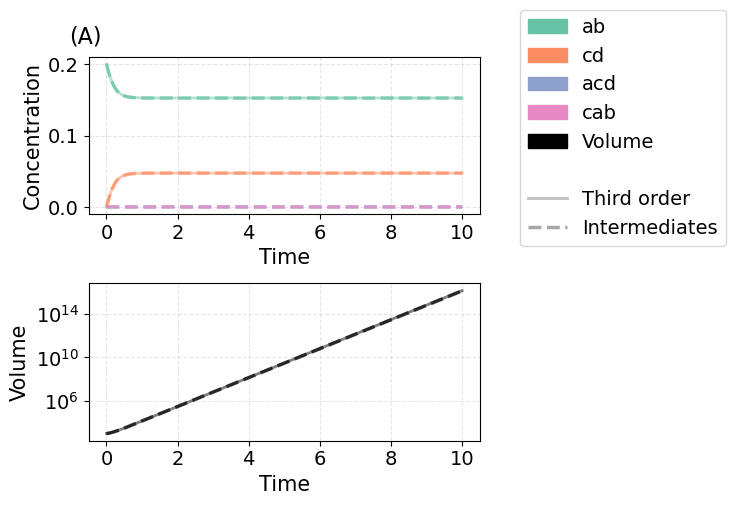

: 

In [ ]:
t_end = 10
for i in np.logspace(-3, 1, 5):
    #k'1 = i 
    print(f"Running for k'1 = {i}")
    K_thirdorder = [i,1,1,1]
    def odes_thirdorder(t, X, K_thirdorder):
        V, ab, cd= X
        a, b, c, d = 1, 1, 1, 1
        k1, k2, k3, k4 = K_thirdorder
        fi = 0.2
        # with concentrations
        dVdt = (V/fi) * (k1 * a * b * cd - k2 * ab * cd + k3 * ab * c * d - k4 * ab * cd)
        dabdt = k1 * a * b * cd - k2 * ab * cd - (ab / V) * dVdt # dilution: as the volume grows, concentration decreases
        dcddt = k3 * ab * c * d - k4 * ab * cd - (cd / V) * dVdt
        return [dVdt, dabdt, dcddt]

    t_span = (0, t_end)
    y0 = [1000, 0.2, 0]
    sol2 = solve_ivp(odes_thirdorder, t_span, y0, t_eval=np.linspace(0, t_end, 500), method='BDF', args=(K_thirdorder,))


    # --- intermediates ---
    K_intermediates = [1e4,1e7,1,1, 1e4,1e7,1e3,1]
    # k_3 = i * k_2 / k_1
    K_intermediates[2] = i * K_intermediates[1] / K_intermediates[0] 
    print(f"Running for k_3 = {K_intermediates[2]} (derived from k'1 = {i})")
    def odes_intermediates(t, X, K_intermediates):
        V, ab, cd, acd, cab = X
        a, b, c, d = 1, 1, 1, 1
        k1, k2, k3, k4, k5, k6, k7, k8 = K_intermediates
        fi = 0.2
        dVdt = (V/fi) * (k3 * b * acd + k7 * d * cab - k4 * ab * cd - k8 * ab * cd)
        dabdt = k3 * b * acd + k6 * cab + k7 * cab * d - k4 * ab * cd - k5 * ab * c - k8 * cd * ab - (ab / V) * dVdt
        dcddt = k3 * b * acd + k7 * cab * d + k2 * acd - k4 * ab * cd - k1 * a * cd - k8 * cd * ab - (cd / V) * dVdt
        dacddt = k4 * ab * cd + k1 * a * cd - k3 * b * acd - k2 * acd - (acd / V) * dVdt
        dcabdt = k5 * ab * c + k8 * cd * ab - k6 * cab - k7 * cab * d - (cab / V) * dVdt
        return [dVdt, dabdt, dcddt, dacddt, dcabdt]
        

    t_span = (0, t_end)
    y0 = [1000, 0.2, 0, 0, 0]
    sol = solve_ivp(odes_intermediates, t_span, y0, t_eval=np.linspace(0, t_end, 500), method='BDF', args=(K_intermediates,))

    plot_deterministic_both(sol2.y[1:3], sol2.t, sol2.y[0], ['ab', 'cd'],
                            sol.y[1:], sol.t, sol.y[0], ['ab', 'cd', 'acd', 'cab'])

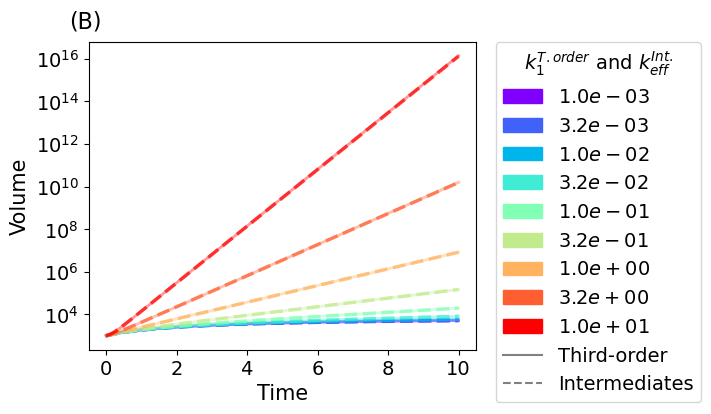

In [7]:
import matplotlib.lines as mlines
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
t_end = 10
values = np.logspace(-3, 1, 9)
colors_sweep = plt.get_cmap('rainbow')(np.linspace(0, 1, len(values)))
plt.figure(figsize=(5,4))

for n, i in enumerate(values):
    #k'1 = i 
    K_thirdorder = [i,1,1,1]
    def odes_thirdorder(t, X, K_thirdorder):
        V, ab, cd= X
        a, b, c, d = 1, 1, 1, 1
        k1, k2, k3, k4 = K_thirdorder
        fi = 0.2
        # with concentrations
        dVdt = (V/fi) * (k1 * a * b * cd - k2 * ab * cd + k3 * ab * c * d - k4 * ab * cd)
        dabdt = k1 * a * b * cd - k2 * ab * cd - (ab / V) * dVdt # dilution: as the volume grows, concentration decreases
        dcddt = k3 * ab * c * d - k4 * ab * cd - (cd / V) * dVdt
        return [dVdt, dabdt, dcddt]

    t_span = (0, t_end)
    y0 = [1000, 0.2, 0]
    sol2 = solve_ivp(odes_thirdorder, t_span, y0, t_eval=np.linspace(0, t_end, 500), method='BDF', args=(K_thirdorder,))
    plt.plot(sol2.t, sol2.y[0], label=fr"$k_1$ = {i:.1e} (third-order)", color=colors_sweep[n], alpha=0.4, linewidth=2)
   

    # --- intermediates ---
    K_intermediates = [1e4,1e7,1,1, 1e4,1e7,1e3,1]
    # k_3 = i * k_2 / k_1
    K_intermediates[2] = i * K_intermediates[1] / K_intermediates[0] 
    def odes_intermediates(t, X, K_intermediates):
        V, ab, cd, acd, cab = X
        a, b, c, d = 1, 1, 1, 1
        k1, k2, k3, k4, k5, k6, k7, k8 = K_intermediates
        fi = 0.2
        dVdt = (V/fi) * (k3 * b * acd + k7 * d * cab - k4 * ab * cd - k8 * ab * cd)
        dabdt = k3 * b * acd + k6 * cab + k7 * cab * d - k4 * ab * cd - k5 * ab * c - k8 * cd * ab - (ab / V) * dVdt
        dcddt = k3 * b * acd + k7 * cab * d + k2 * acd - k4 * ab * cd - k1 * a * cd - k8 * cd * ab - (cd / V) * dVdt
        dacddt = k4 * ab * cd + k1 * a * cd - k3 * b * acd - k2 * acd - (acd / V) * dVdt
        dcabdt = k5 * ab * c + k8 * cd * ab - k6 * cab - k7 * cab * d - (cab / V) * dVdt
        return [dVdt, dabdt, dcddt, dacddt, dcabdt]
        

    t_span = (0, t_end)
    y0 = [1000, 0.2, 0, 0, 0]
    sol = solve_ivp(odes_intermediates, t_span, y0, t_eval=np.linspace(0, t_end, 500), method='BDF', args=(K_intermediates,))

    plt.plot(sol.t, sol.y[0], label=fr"$k_3$ = {i:.1e} (intermediate)", color=colors_sweep[n], alpha=0.7, linewidth=2.5, linestyle='--')

plt.xlabel("Time", fontsize= label_fs)
plt.ylabel("Volume", fontsize= label_fs)
plt.yscale('log')
# Create custom legend handles
handles, labels = plt.gca().get_legend_handles_labels()

# Option A: Just show the unique K values
# We take every 2nd handle (0, 2, 4...) because they share the same color
unique_handles = handles[::2] 
unique_labels = [f'$k = {val:.1e}$' for val in [1e-3, 1e-2, 1e-1, 1, 10, 100]]

# Option B: Add a 'Key' for the line styles

line_to = mlines.Line2D([], [], color='gray', linestyle='-', label='Third-order')
line_int = Line2D([], [], color='gray', linestyle='--', label='Intermediates')



# Create legend handles for the species (colored patches)
species_handles = [Patch(color=c, label=name) for c, name in zip(colors_sweep, [f'${val:.1e}$' for val in values])]

handles = species_handles + [line_to, line_int]

plt.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.,
           fontsize= legend_fs, title=r"$k_1^{T. order}$ and $k_{eff}^{Int.}$", title_fontsize= legend_fs)
plt.title("(B)", loc="left",x = -0.05, y=1, pad=10, fontsize=16)
plt.tick_params(axis='both', labelsize=tick_fs)
spacer = Patch(color='none', label='')
handles = species_handles + [spacer] + [line_to, line_int]
plt.savefig("../figures_TFM/volume_sweep_third_order.png", bbox_inches='tight')
